# Figure S1

![Full Figure](../figures/suppS1_FULL.png)

## Code For Figure S1 (Key + A–H): Comparison of Task Metrics Across Curricula Phases

**Goal:** Compare behavioral metrics (trials/session, hit rate, no-answer rate, rigs, days) across three curricula phases (Side Poke, Fixation Growth, Probe) between Legacy and FixGrower cohorts; show individual and cohort-level stage progressions aligned to the start of the Fixation Growth curriculum.

| Panel | Description | Data source |
|-------|-------------|-------------|
| Key   | Animal color legend (Legacy / FixGrower cohort mapping) | `config` |
| A     | Trials per session by curricula phase; mixed LM + Holm | `trials_df` |
| B     | Hit rate by curricula phase; mixed LM + Holm | `trials_df` |
| C     | No-answer rate by curricula phase; mixed LM + Holm | `trials_df` |
| D     | Number of rigs per animal × phase (R044 excluded); Welch/MWU + Holm | `days_df` |
| E     | Days in each curriculum phase; Welch/MWU + Holm | `days_df` |
| F     | Mean stage progression by cohort, aligned to Stage 5 | `trials_df` |
| G     | Individual Legacy stage progressions, aligned to Stage 5 | `trials_df` |
| H     | Individual FixGrower stage progressions, aligned to Stage 5 | `trials_df` |

**Outputs:**
- `figures/suppS1_animals_legacy_fixgrower_legend.png`
- `figures/suppS1a_trials_per_session_by_stage_type.png`
- `figures/suppS1b_hit_rate_by_stage_type.png`
- `figures/suppS1c_no_answer_rate_by_stage_type.png`
- `figures/suppS1d_n_rigs_by_stage_type.png`
- `figures/suppS1e_n_days_by_stage_type.png`
- `figures/suppS1f_average_stage_progression.png`
- `figures/suppS1g_legacy_stage_progressions.png`
- `figures/suppS1h_fixgrower_stage_progressions.png`

In [1]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from fixation_grower import config
from fixation_grower.io import load_days_df, load_trials_df
from fixation_grower.plotting import (
    box_strip_legacy_vs_fixgrower,
    plot_stage_progression,
    save_figure,
)
from fixation_grower.stats import (
    compare_supp_s1_animal_metrics_by_stage_holm,
    compare_supp_s1_session_metrics_mixedlm_holm,
)
from fixation_grower.transforms import (
    STAGE_CURRICULUM_LABELS,
    STAGE_TYPE_ORDER,
    add_stage_type_column,
    make_hit_rate_df,
    make_n_days_stage_type_df,
    make_no_answer_rate_df,
    make_rig_switch_df,
    make_supp_s1_trials_df,
)

sns.set_context(
    "notebook",
    rc={
        "font.size": 18,
        "axes.titlesize": 18,
        "axes.labelsize": 18,
        "axes.titleweight": "bold",
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "lines.linewidth": 2,
        "lines.markersize": 7,
    },
)

In [2]:
# ---------------------------------------------------------------------------
# Shared prep: load, add stage_type, build panel DataFrames
# ---------------------------------------------------------------------------
tdf = add_stage_type_column(load_trials_df(stages="all"))
ddf = add_stage_type_column(load_days_df(stages="all"))

# Panels A–C: session-level metrics
trials_df = make_supp_s1_trials_df(tdf)      # Panel A
hit_rate_df = make_hit_rate_df(tdf)             # Panel B
no_answer_df = make_no_answer_rate_df(tdf)       # Panel C

# Panels D–E: animal-level metrics from days_df
# Panel D (R044 excluded per methods)
rig_df = make_rig_switch_df(ddf)
rig_df_no_r044 = rig_df.query("animal_id != 'R044'").copy()
n_days_df = make_n_days_stage_type_df(tdf)    # Panel E

## Key — Animal color legend (upper-left)

Each dot in panels A–E is colored by animal ID. This panel shows the mapping between animal ID and color, grouped by curriculum arm (Legacy vs FixGrower).

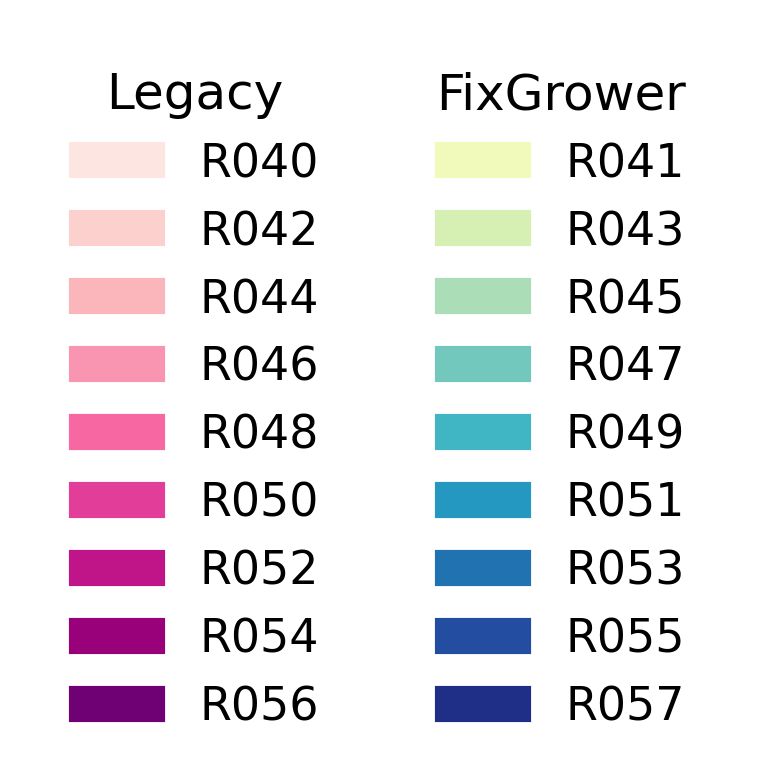

In [3]:
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)
ax.set_axis_off()

legacy_handles = [
    mpatches.Patch(color=config.ANIMAL_PALETTE[a], label=a)
    for a in config.LEGACY_ANIMALS
]
fg_handles = [
    mpatches.Patch(color=config.ANIMAL_PALETTE[a], label=a)
    for a in config.FIXGROWER_ANIMALS
]

leg_legacy = ax.legend(
    handles=legacy_handles,
    title="Legacy",
    loc="upper left",
    frameon=False,
    ncol=1,
    fontsize=11,
    title_fontsize=12,
)
ax.add_artist(leg_legacy)
ax.legend(
    handles=fg_handles,
    title="FixGrower",
    loc="upper right",
    frameon=False,
    ncol=1,
    fontsize=11,
    title_fontsize=12,
)

save_figure(fig, "suppS1_animals_legacy_fixgrower_legend")
plt.show()

## Panel A — Trials per session by curricula phase

Trials counted per session per animal. For Side Poke (stages 1–4) this is unique trial count; for Fixation Growth and Probe it is the total number of center-poke settling-ins (a session-equivalent measure). Sessions with ≥900 trials are excluded (Bpod error days).

Statistics: mixed linear model `n_trials ~ C(fix_experiment, Treatment(reference="Legacy"))` with random intercept for `animal_id`, fitted once per phase, Holm-corrected across phases.

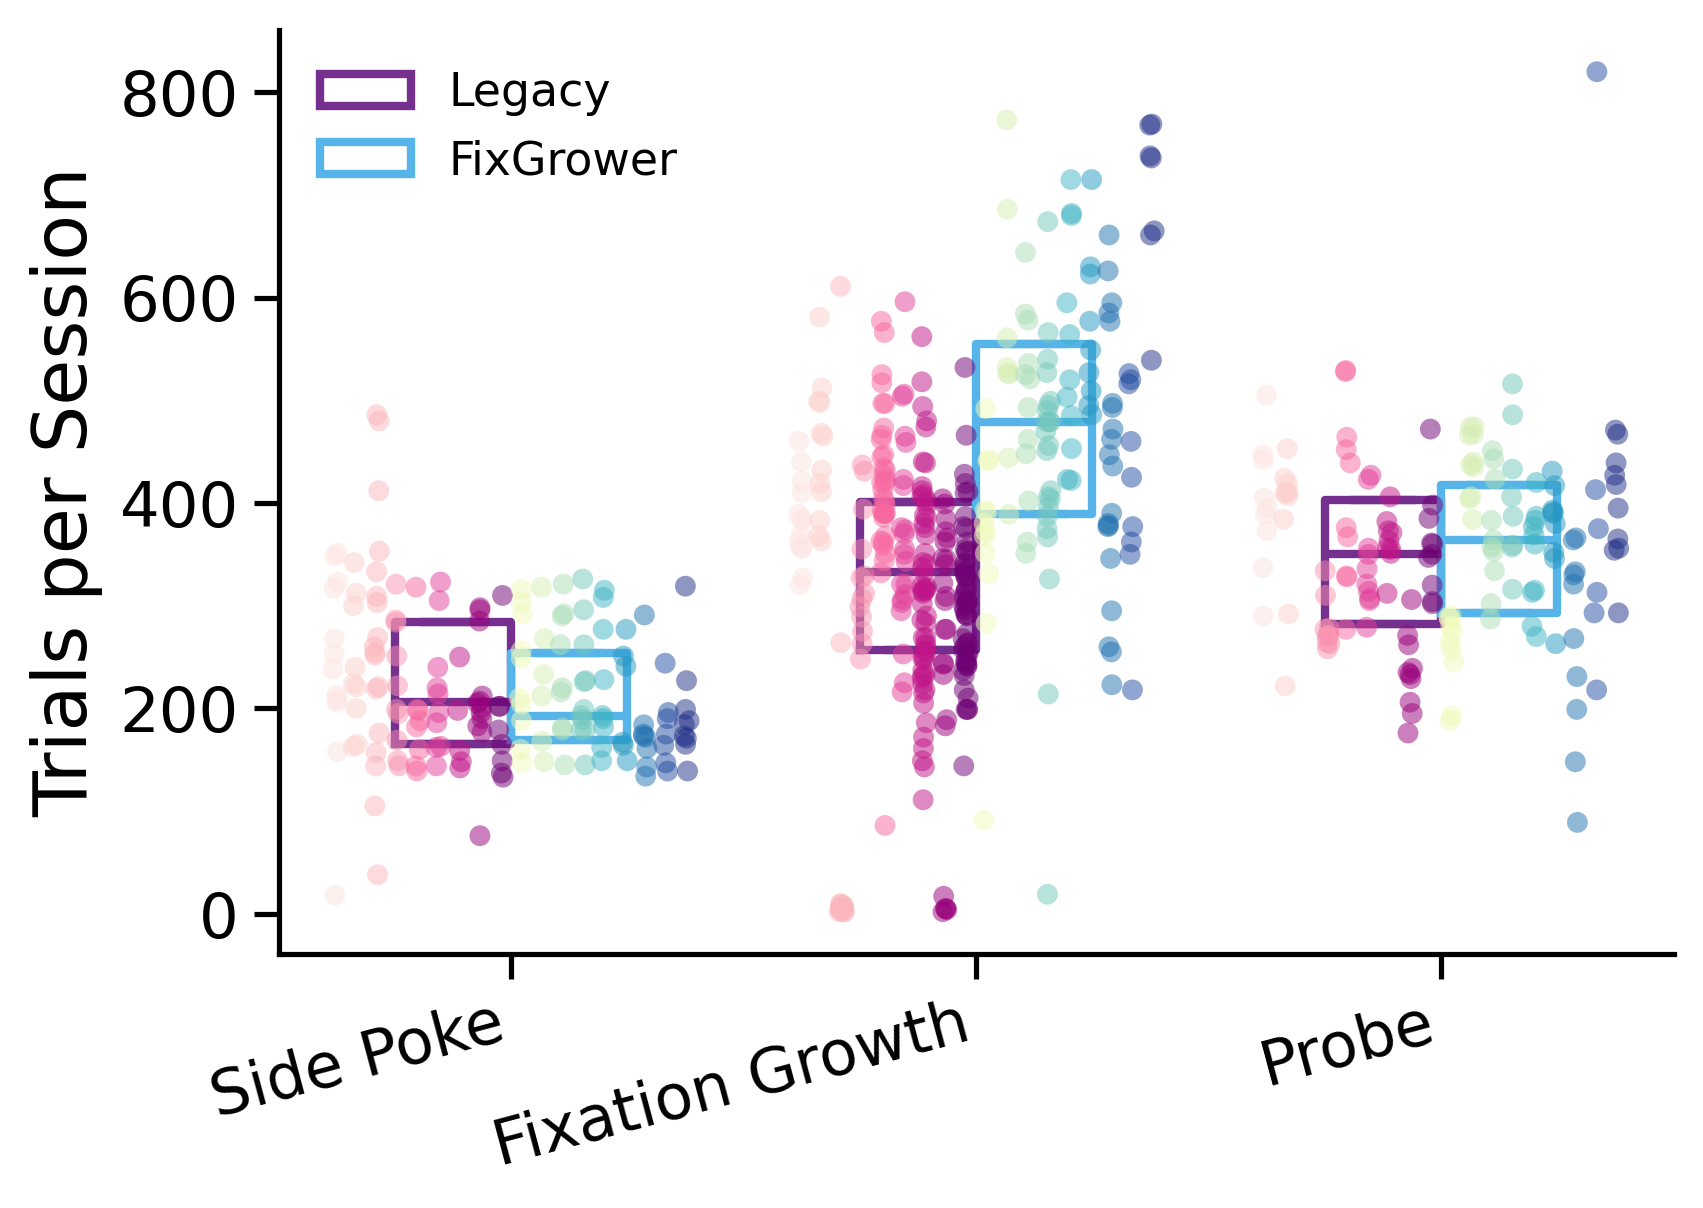

/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


,stage_type,test_type,test_statistic,p_val_raw,residuals_normal,p_val_holm,reject_h0_holm
0,spoke,mixedlm_random_intercept,-0.809174,0.418415,False,0.836830,0.0
1,grow_fix,mixedlm_random_intercept,3.582253,0.000341,False,0.001022,1.0
2,probe,mixedlm_random_intercept,0.525607,0.599161,False,0.836830,0.0


In [4]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
box_strip_legacy_vs_fixgrower(
    data=trials_df,
    x="stage_type",
    order=STAGE_TYPE_ORDER,
    y="n_trials",
    ax=ax,
    hue_type="animal",
    ylabel="Trials per Session",
    xlabel="",
    alpha=0.5,
)
ax.set_xticks(range(len(STAGE_TYPE_ORDER)))
ax.set_xticklabels(STAGE_CURRICULUM_LABELS, rotation=15, ha="right")
sns.despine()
save_figure(fig, "suppS1a_trials_per_session_by_stage_type")
plt.show()

stats_a = compare_supp_s1_session_metrics_mixedlm_holm(
    trials_df, metric_col="n_trials")
display(stats_a)

## Panel B — Hit rate by curricula phase

Hit rate per session: mean of `hits` per `(animal_id, fix_experiment, stage_type, date)`. Same mixed-LM + Holm statistics as Panel A.

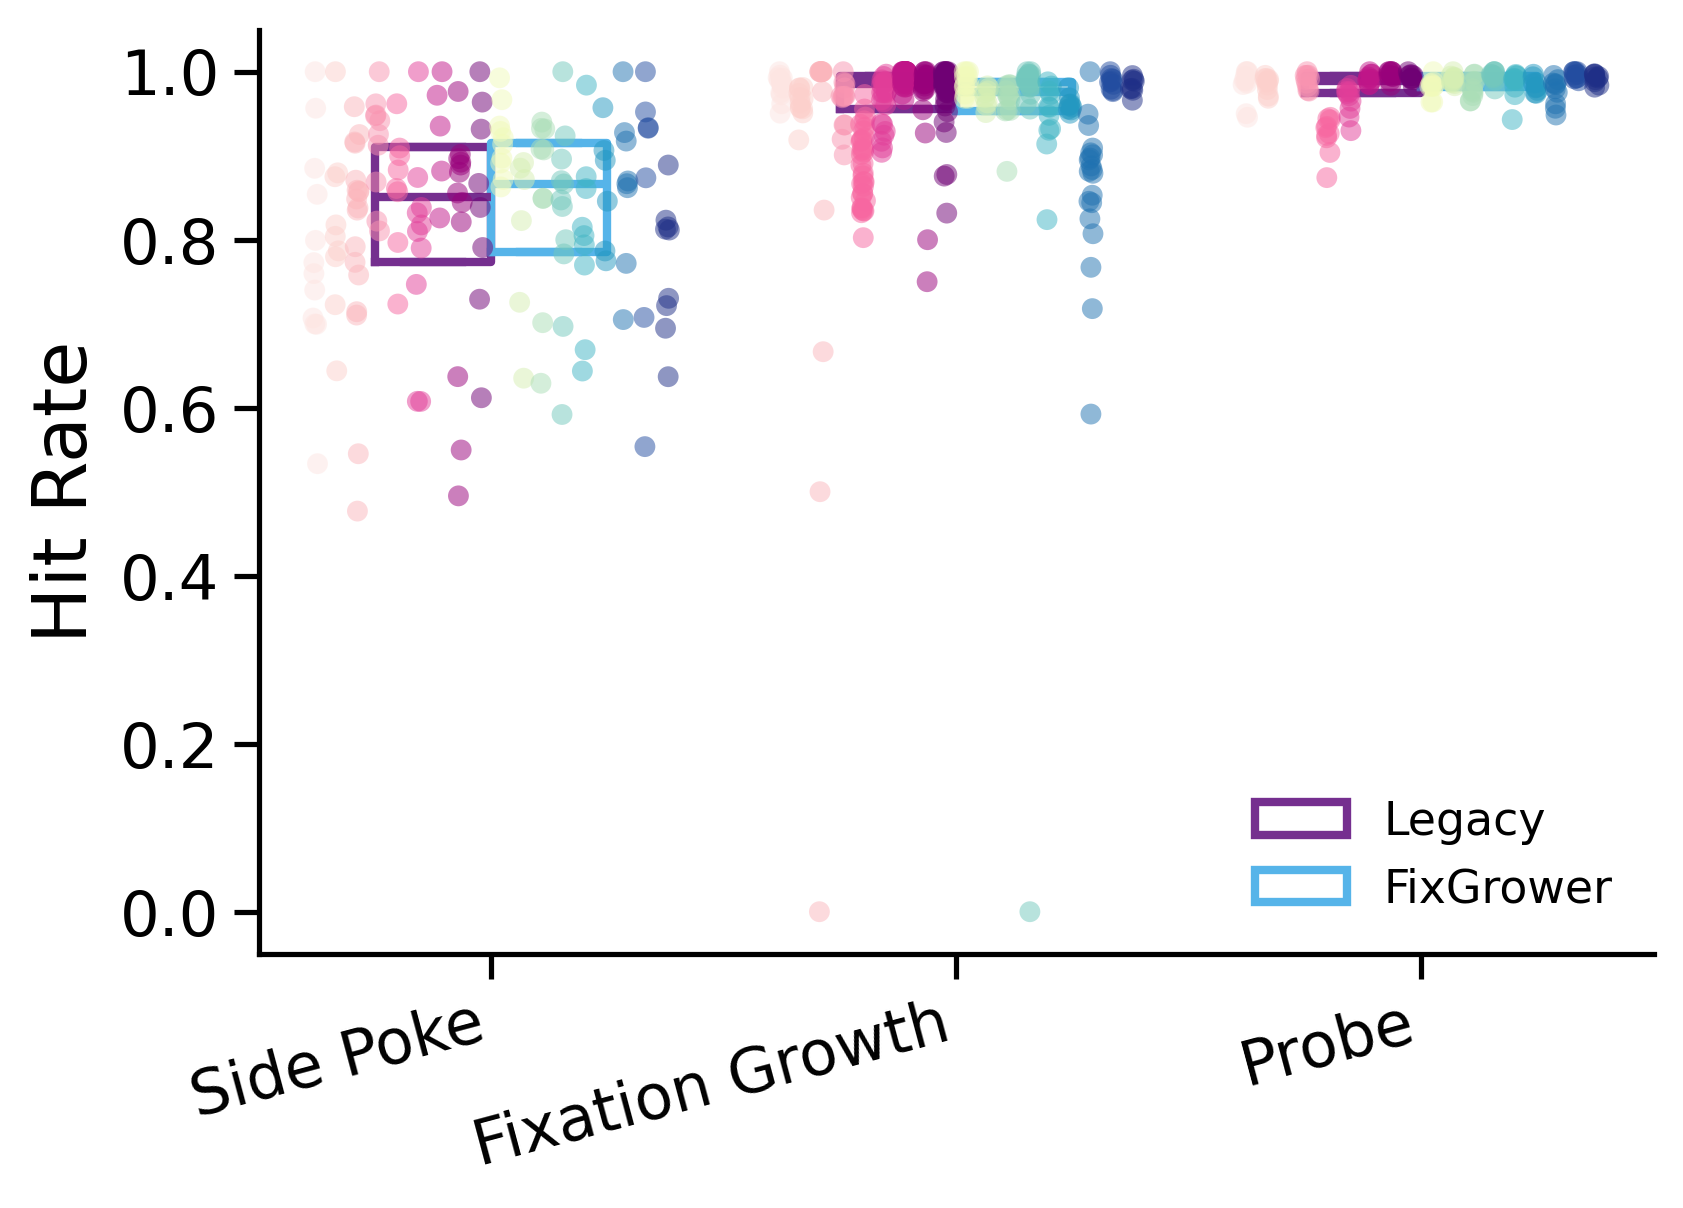

/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on t

,stage_type,test_type,test_statistic,p_val_raw,residuals_normal,p_val_holm,reject_h0_holm
0,spoke,mixedlm_random_intercept,0.370292,0.711165,False,1.0,0.0
1,grow_fix,mixedlm_random_intercept,0.104080,0.917106,False,1.0,0.0
2,probe,mixedlm_random_intercept,0.962820,0.335638,False,1.0,0.0


In [5]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
box_strip_legacy_vs_fixgrower(
    data=hit_rate_df,
    x="stage_type",
    order=STAGE_TYPE_ORDER,
    y="hit_rate",
    ax=ax,
    hue_type="animal",
    ylabel="Hit Rate",
    xlabel="",
    alpha=0.5,
)
ax.set_xticks(range(len(STAGE_TYPE_ORDER)))
ax.set_xticklabels(STAGE_CURRICULUM_LABELS, rotation=15, ha="right")
sns.despine()
save_figure(fig, "suppS1b_hit_rate_by_stage_type")
plt.show()

stats_b = compare_supp_s1_session_metrics_mixedlm_holm(
    hit_rate_df, metric_col="hit_rate")
display(stats_b)

## Panel C — No-answer rate by curricula phase

No-answer rate: fraction of valid trials where `result == 6` (no side poke within the 8 s answer period) per session. Same mixed-LM + Holm statistics as Panel A.

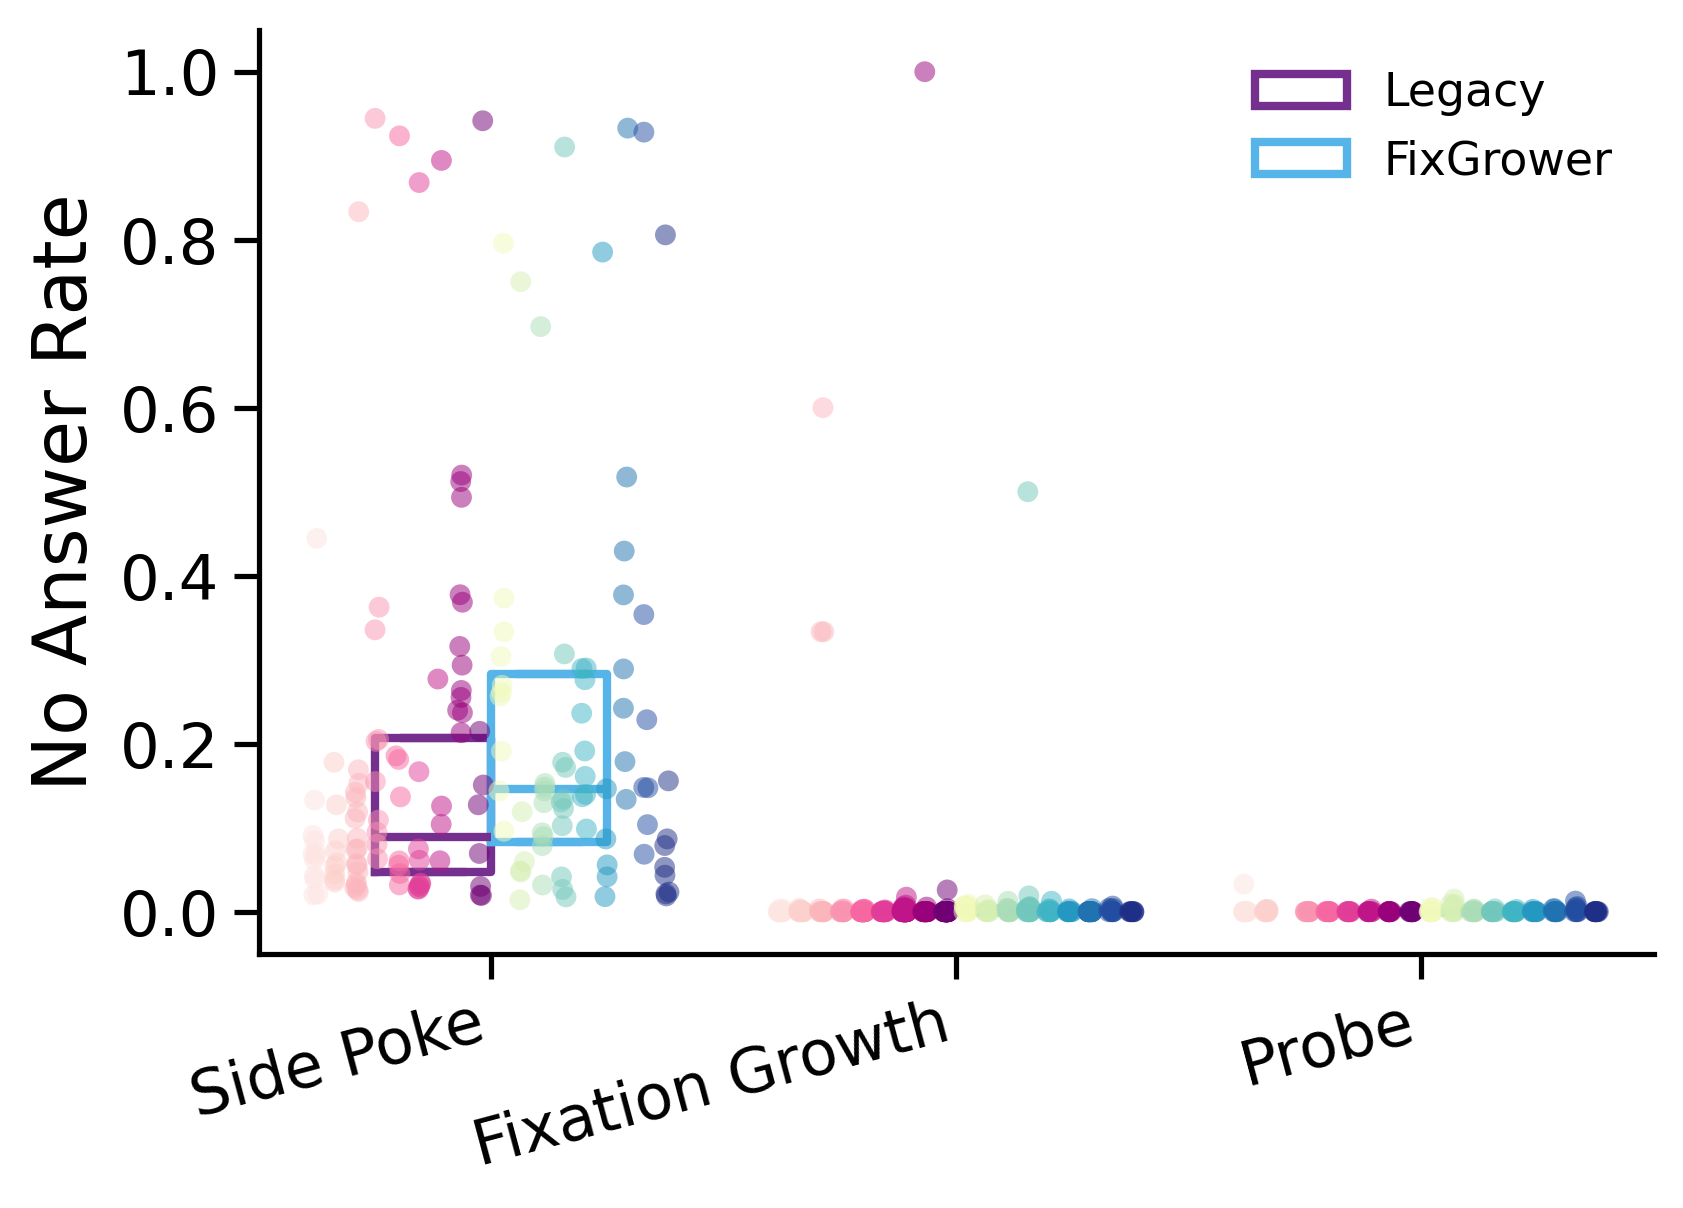

/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance 

,stage_type,test_type,test_statistic,p_val_raw,residuals_normal,p_val_holm,reject_h0_holm
0,spoke,mixedlm_random_intercept,1.037331,0.299582,False,0.898745,0.0
1,grow_fix,mixedlm_random_intercept,-0.616886,0.537310,False,0.898745,0.0
2,probe,mixedlm_random_intercept,0.903141,0.366451,False,0.898745,0.0


In [6]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
box_strip_legacy_vs_fixgrower(
    data=no_answer_df,
    x="stage_type",
    order=STAGE_TYPE_ORDER,
    y="no_answer_rate",
    ax=ax,
    hue_type="animal",
    ylabel="No Answer Rate",
    xlabel="",
    alpha=0.5,
)
ax.set_xticks(range(len(STAGE_TYPE_ORDER)))
ax.set_xticklabels(STAGE_CURRICULUM_LABELS, rotation=15, ha="right")
sns.despine()
save_figure(fig, "suppS1c_no_answer_rate_by_stage_type")
plt.show()

stats_c = compare_supp_s1_session_metrics_mixedlm_holm(
    no_answer_df, metric_col="no_answer_rate")
display(stats_c)

## Panel D — Number of rigs per animal × phase (R044 excluded)

Number of distinct rigs (`n_rigs = rig switches + 1`) each animal trained in within each curricula phase. Animal R044 is excluded per methods (rig-switch rationale described in Methods). Compared across experiment types by Welch's t-test (if both groups pass Shapiro-Wilk) or Mann–Whitney U, Holm-corrected across phases.

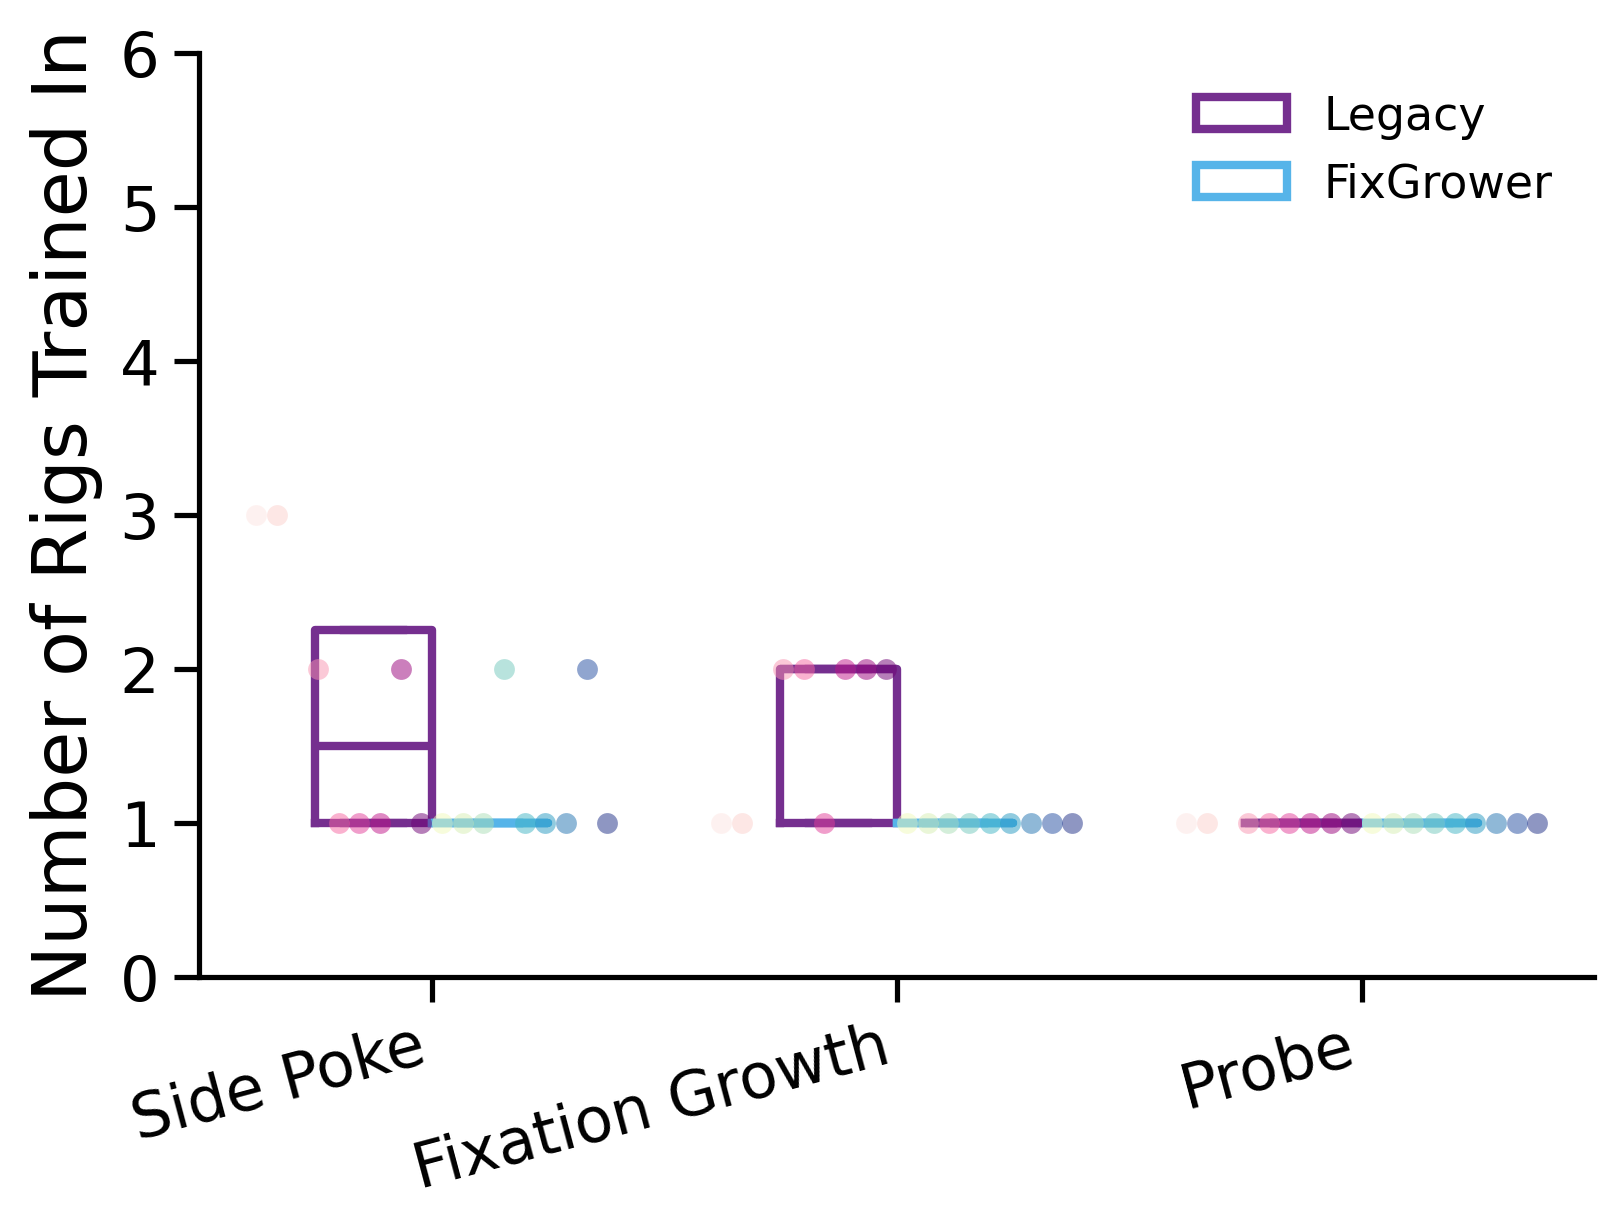

/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,stage_type,normality_Legacy,normality_FixGrower,n_Legacy,n_FixGrower,test_type,test_statistic,p_val_raw,p_val_holm,reject_h0_holm
0,spoke,False,False,8,9,mannwhitney,48.0,0.191236,0.191236,0.0
1,grow_fix,False,True,8,9,mannwhitney,58.5,0.007412,0.014823,1.0
2,probe,True,True,8,9,welch_t,NaN,NaN,NaN,NaN


In [7]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
box_strip_legacy_vs_fixgrower(
    data=rig_df_no_r044,
    x="stage_type",
    order=STAGE_TYPE_ORDER,
    y="n_rigs",
    ax=ax,
    hue_type="animal",
    ylabel="Number of Rigs Trained In",
    xlabel="",
    alpha=0.5,
)
ax.set_xticks(range(len(STAGE_TYPE_ORDER)))
ax.set_xticklabels(STAGE_CURRICULUM_LABELS, rotation=15, ha="right")
sns.despine()
_ = ax.set_ylim(0, 6)
save_figure(fig, "suppS1d_n_rigs_by_stage_type")
plt.show()

stats_d = compare_supp_s1_animal_metrics_by_stage_holm(
    rig_df_no_r044, metric_col="n_rigs")
display(stats_d)

## Panel E — Days in each curricula phase

Number of unique calendar session-days each animal spent in each curricula phase. Same Welch/MWU + Holm statistics as Panel D.

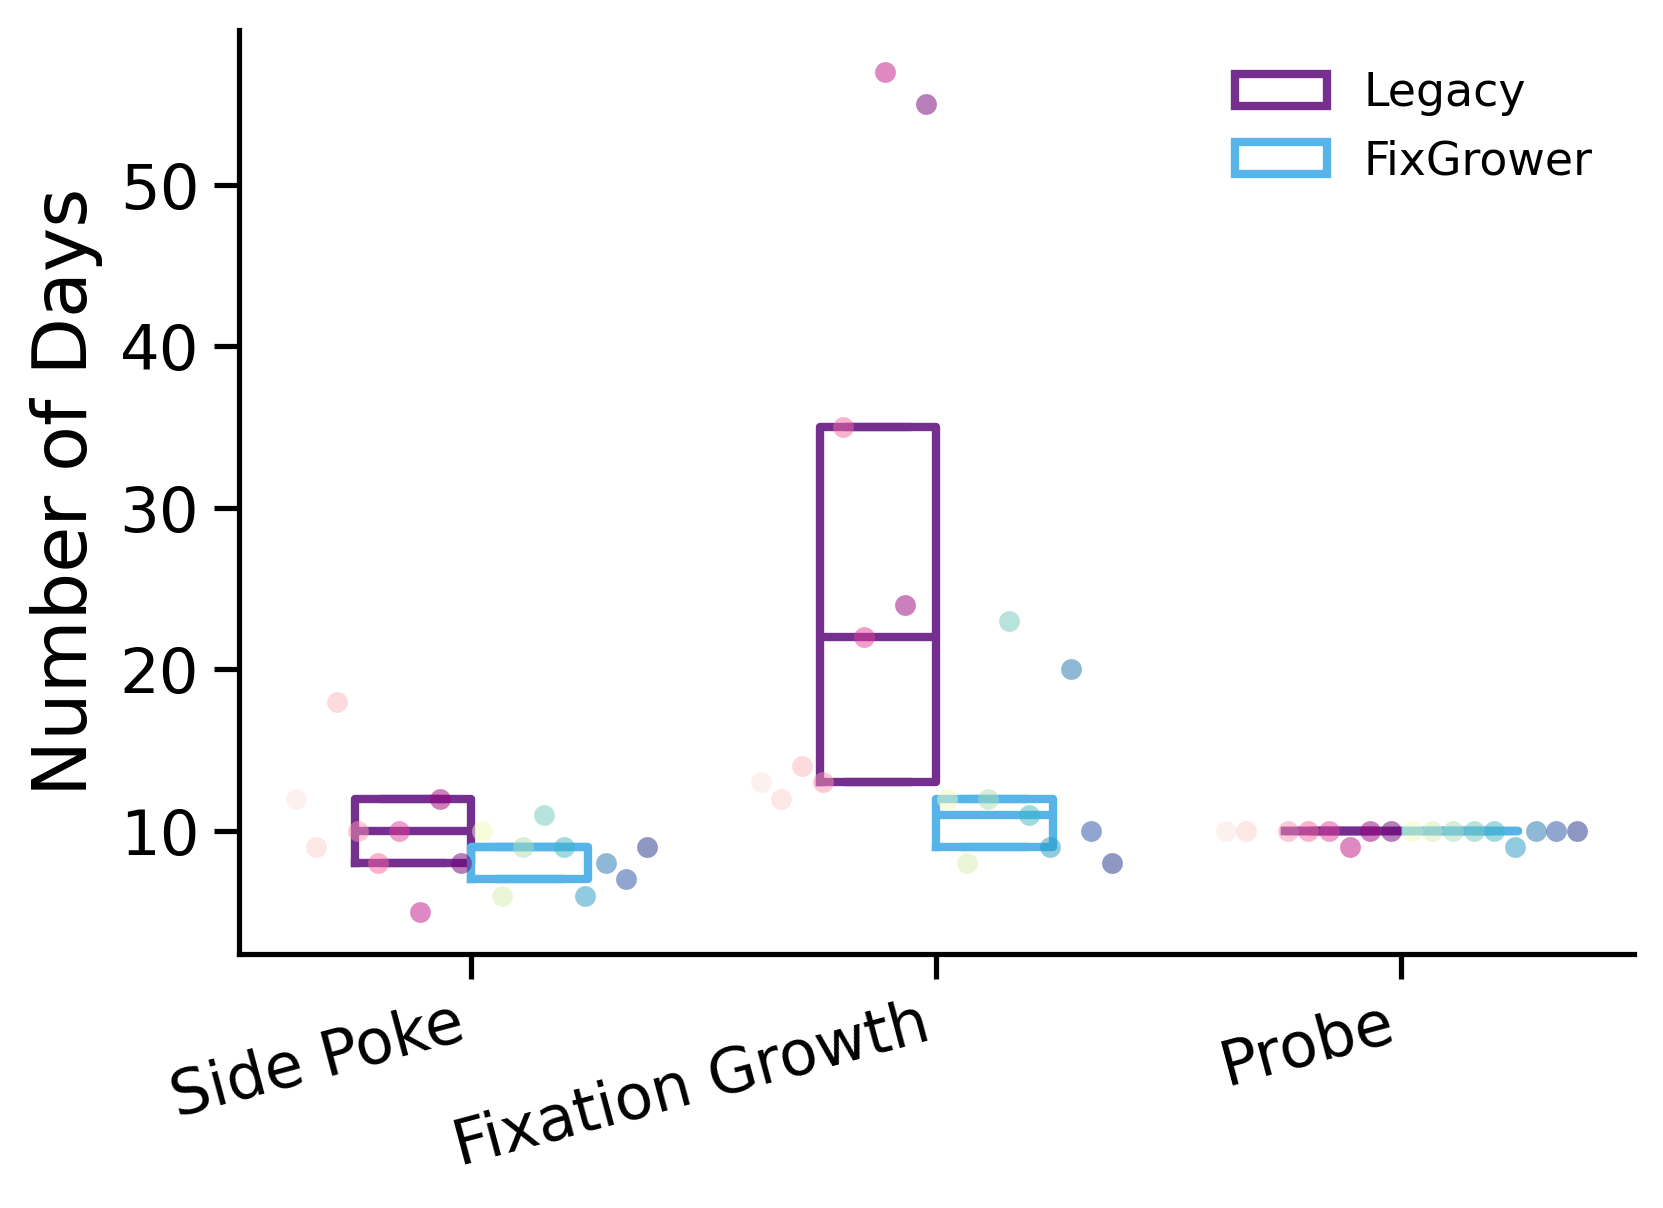

,stage_type,normality_Legacy,normality_FixGrower,n_Legacy,n_FixGrower,test_type,test_statistic,p_val_raw,p_val_holm,reject_h0_holm
0,spoke,True,True,9,9,welch_t,1.408136,0.185638,0.371277,0.0
1,grow_fix,False,False,9,9,mannwhitney,71.000000,0.007877,0.023630,1.0
2,probe,False,False,8,9,mannwhitney,35.500000,1.000000,1.000000,0.0


In [24]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)
box_strip_legacy_vs_fixgrower(
    data=n_days_df,
    x="stage_type",
    order=STAGE_TYPE_ORDER,
    y="n_days_in_stage_type",
    ax=ax,
    hue_type="animal",
    ylabel="Number of Days",
    xlabel="",
    alpha=0.5,
)
ax.set_xticks(range(len(STAGE_TYPE_ORDER)))
ax.set_xticklabels(STAGE_CURRICULUM_LABELS, rotation=15, ha="right")
sns.despine()
save_figure(fig, "suppS1e_n_days_by_stage_type")
plt.show()


stats_e = compare_supp_s1_animal_metrics_by_stage_holm(
    n_days_df, metric_col="n_days_in_stage_type")
display(stats_e)

## Panel F — Average stage progression by cohort, aligned to Stage 5

Mean training stage vs days relative to the first day of the Fixation Growth curriculum (Stage 5). Hue = experiment group (Legacy / FixGrower). Steps show the group mean at each curriculum day.

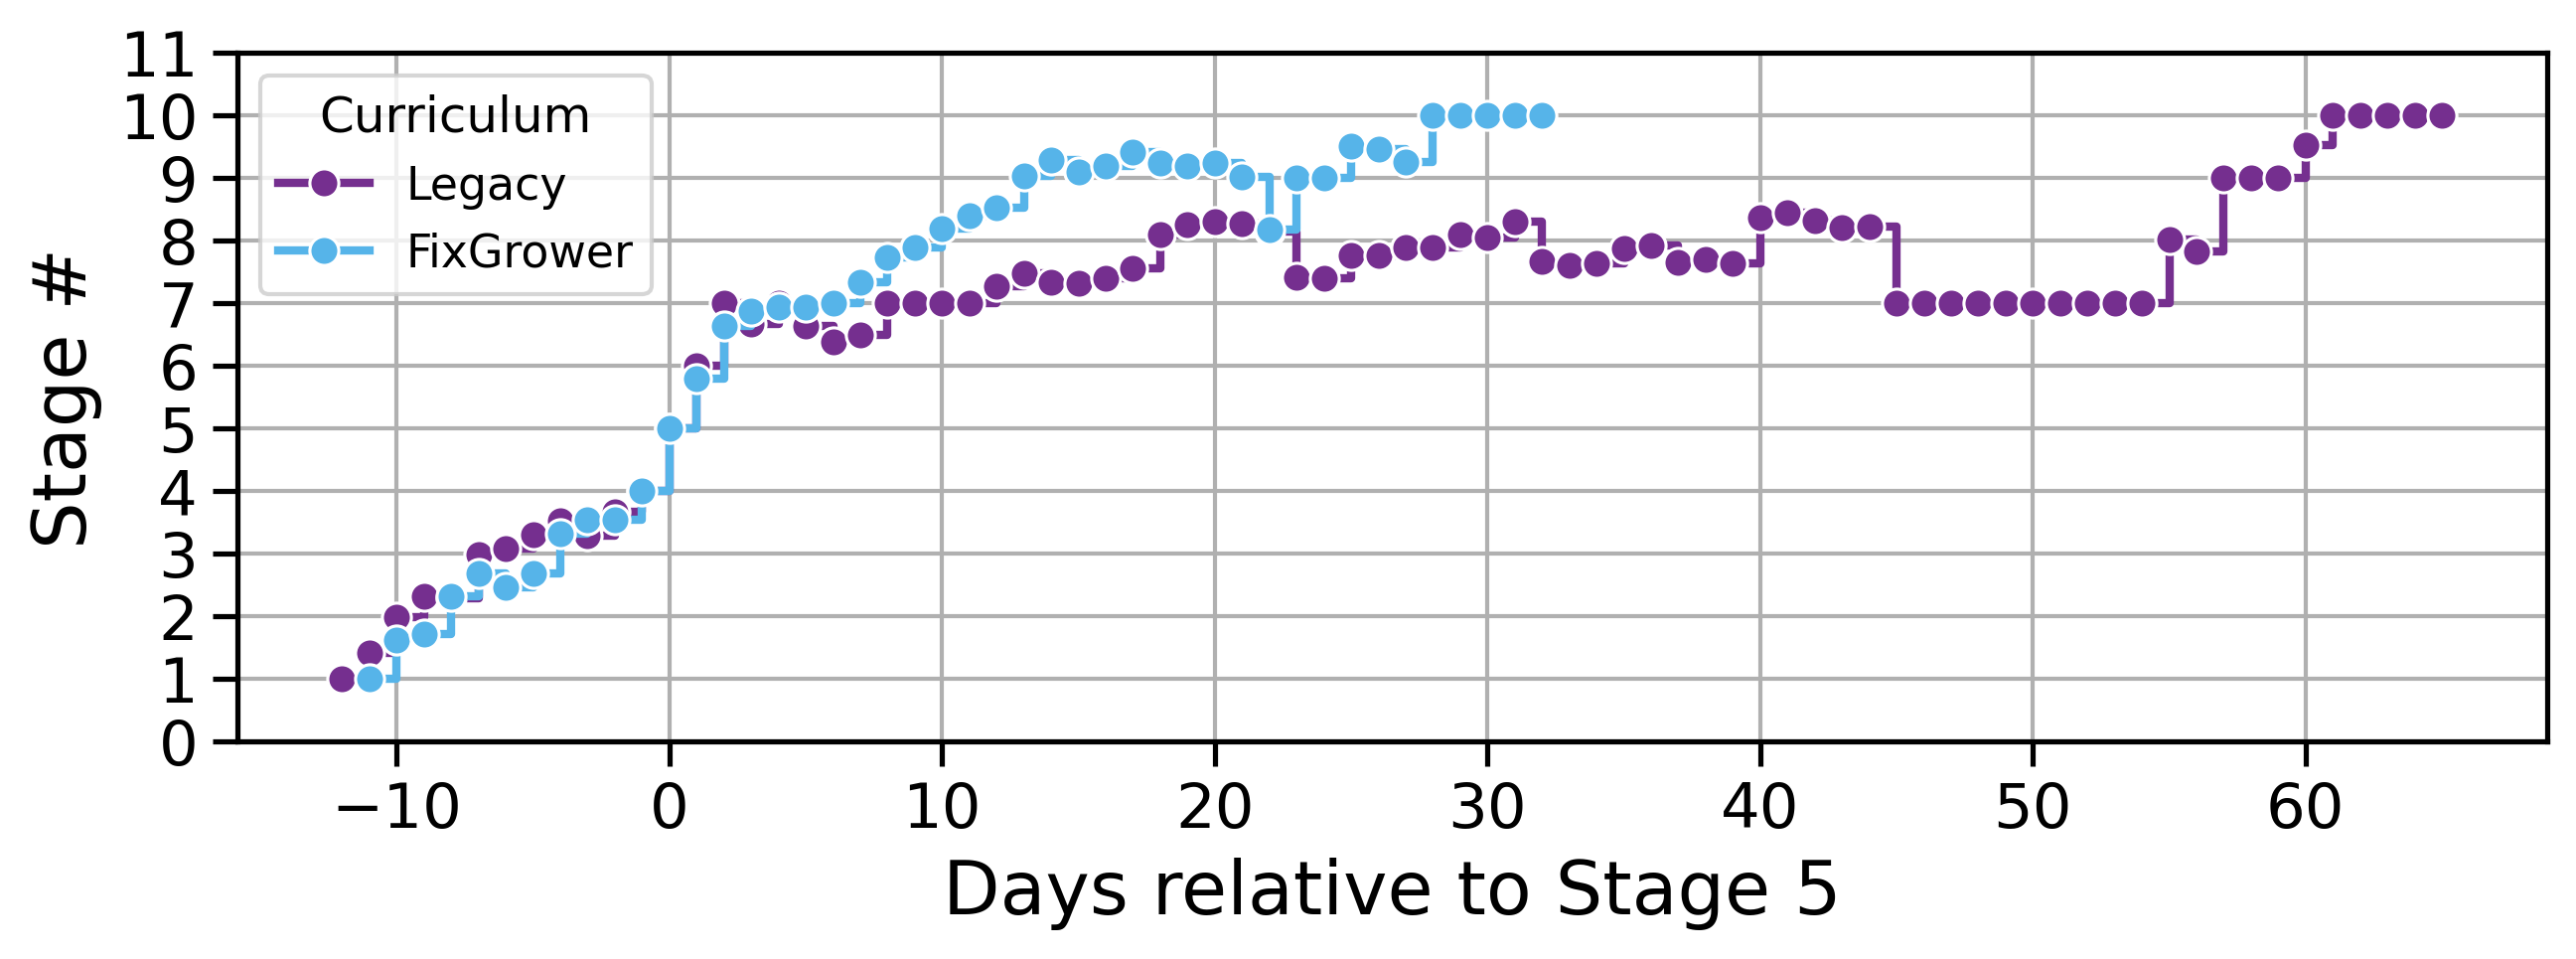

In [21]:
fig, ax = plot_stage_progression(
    tdf,
    figsize=(10, 3),
    relative_to_stage=5,
    hue="fix_experiment",
    palette=dict(zip(config.HUE_ORDER_EXP, config.EXP_PALETTE)),
    xlabel="Days relative to Stage 5",
    legend_title="Curriculum",
    ylim=(0, 11),
)
save_figure(fig, "suppS1f_average_stage_progression")
plt.show()

## Panel G — Individual Legacy stage progressions, aligned to Stage 5

Each line is one Legacy-trained animal. Steps show the animal's maximum stage reached on each curriculum day.

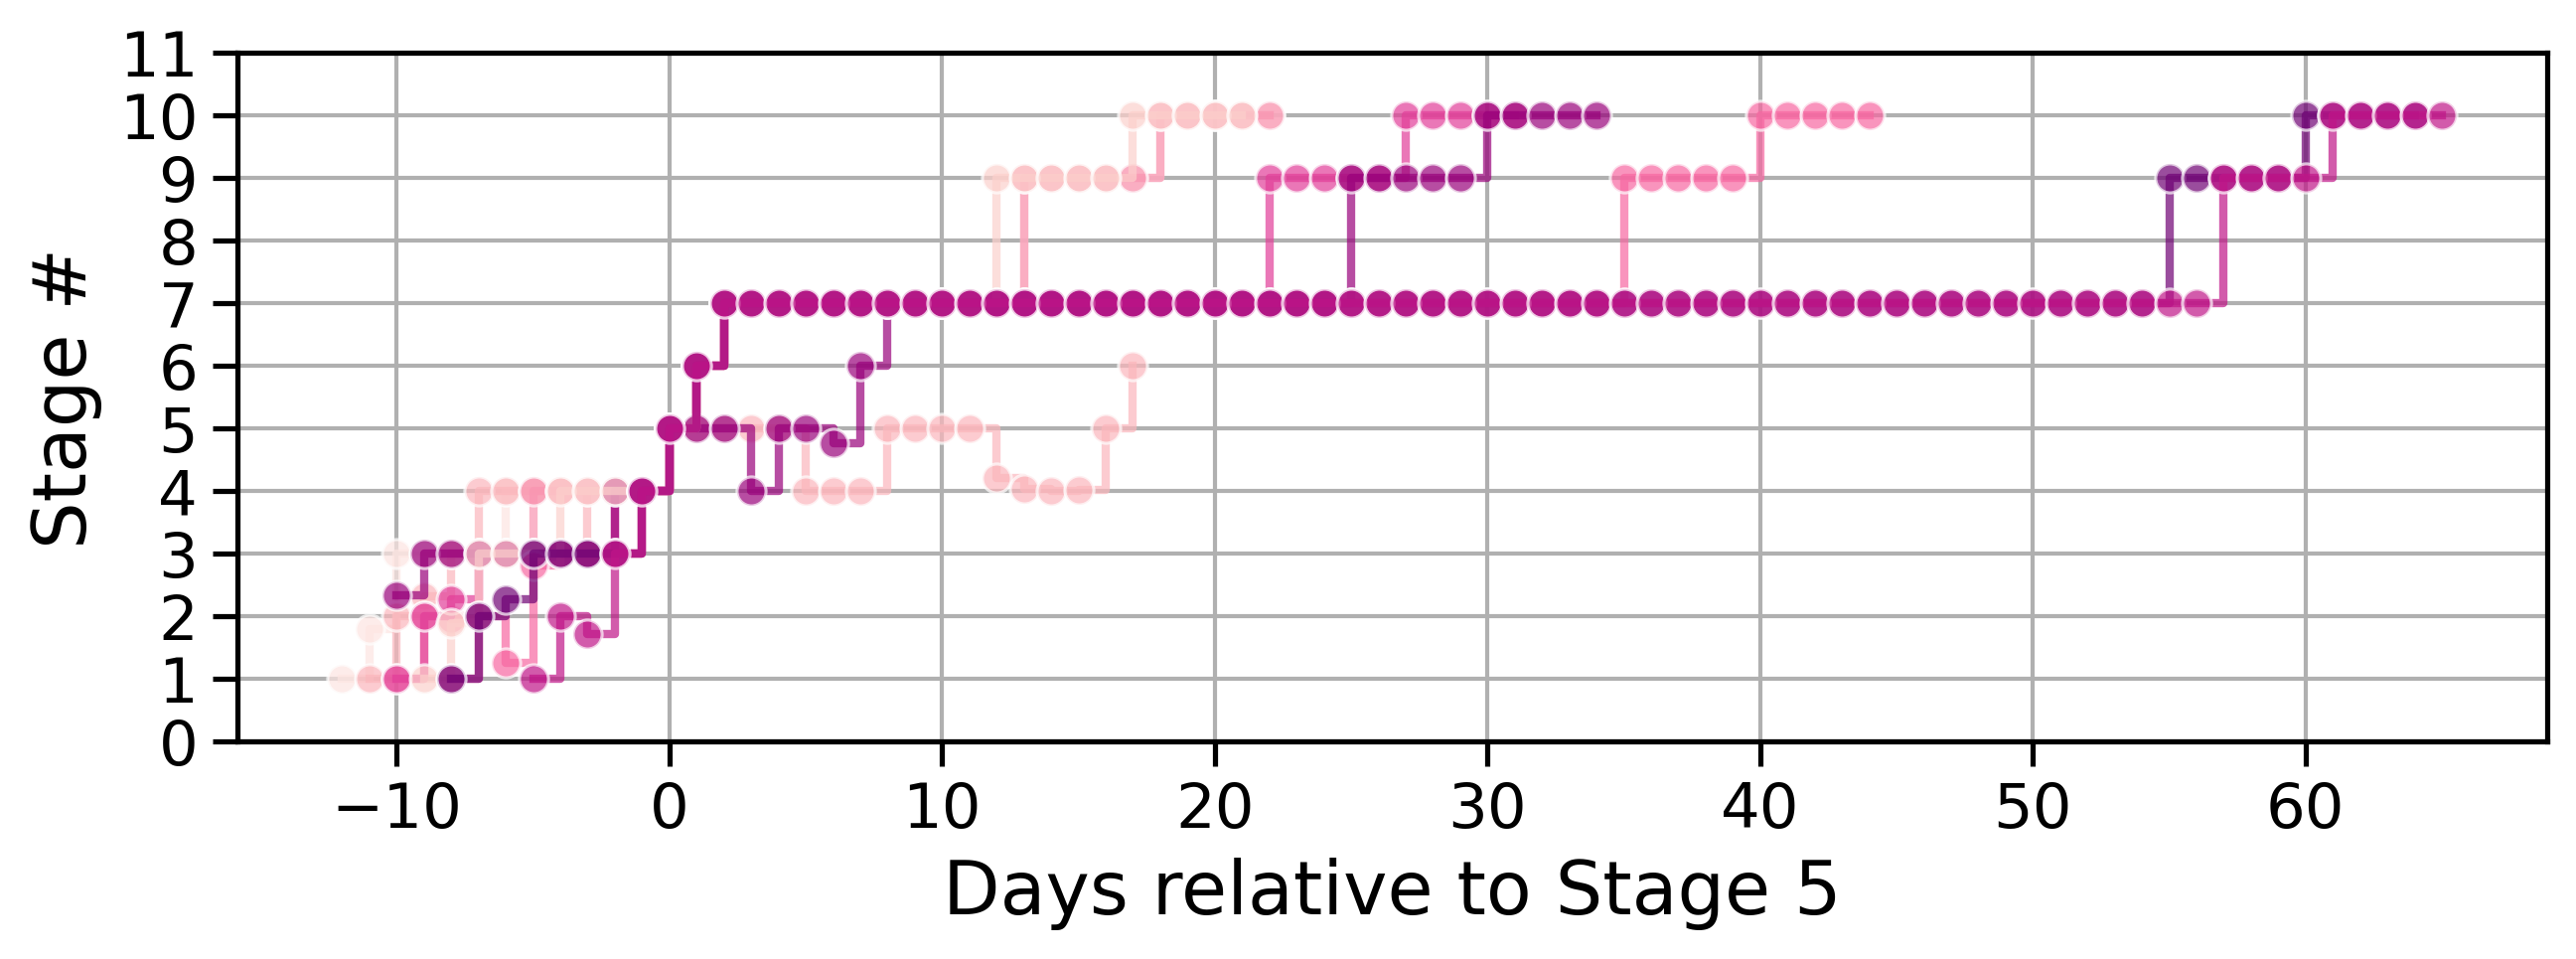

In [20]:
legacy_tdf = tdf.loc[tdf["fix_experiment"] == "Legacy"]
fig, ax = plot_stage_progression(
    legacy_tdf,
    figsize=(10, 3),
    relative_to_stage=5,
    hue="animal_id",
    palette=config.ANIMAL_PALETTE,
    xlabel="Days relative to Stage 5",
    legend_title="Animal",
    ylim=(0, 11),
    alpha=0.7,
)

ax.legend().remove()
save_figure(fig, "suppS1g_legacy_stage_progressions")
plt.show()

## Panel H — Individual FixGrower stage progressions, aligned to Stage 5

Same as Panel G but for FixGrower-trained animals.

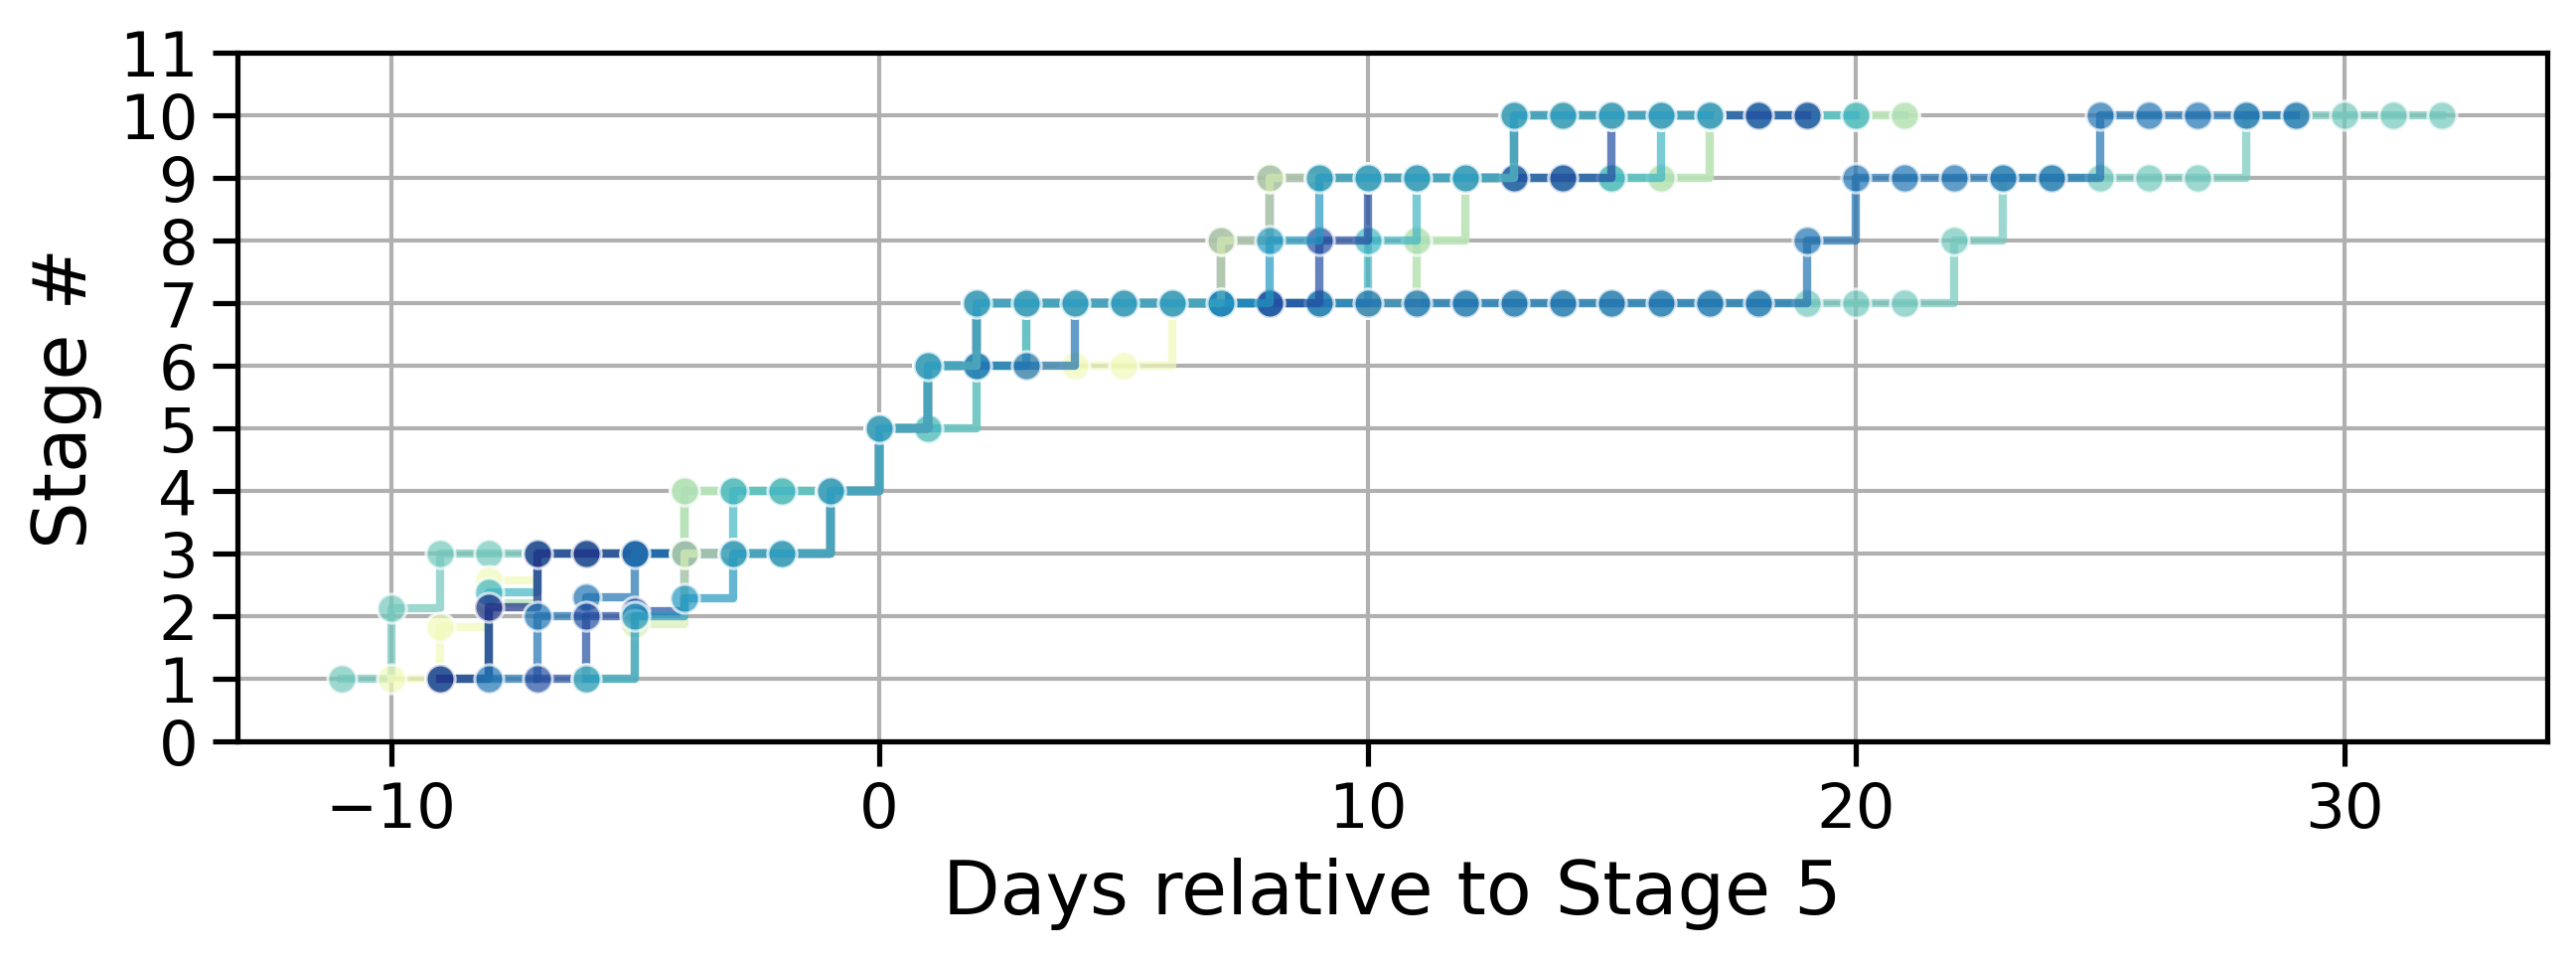

In [19]:
fg_tdf = tdf.loc[tdf["fix_experiment"] == "FixGrower"]
fig, ax = plot_stage_progression(
    fg_tdf,
    figsize=(10, 3),
    relative_to_stage=5,
    hue="animal_id",
    palette=config.ANIMAL_PALETTE,
    xlabel="Days relative to Stage 5",
    legend_title="Animal",
    ylim=(0, 11),
    alpha=0.7,
)

ax.legend().remove()
save_figure(fig, "suppS1h_fixgrower_stage_progressions")
plt.show()